In [1]:
import torch
import numpy as np
import random
import os

from transformer_sac.config import *
from transformer_sac.data_loader import load_stocks
from transformer_sac.sac_trainer import SACTrainer
from transformer_sac.backtest import backtest, plot_equity, compute_buyhold_equity

print("Device:", DEVICE)

Device: cuda


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Seed fixed.")

Seed fixed.


In [3]:
train_states, train_prices = load_stocks(mode="train")
val_states, val_prices     = load_stocks(mode="val")
test_states, test_prices   = load_stocks(mode="test")

print("Train files:", len(train_states))
print("Val files:", len(val_states))
print("Test files:", len(test_states))

Train files: 10
Val files: 10
Test files: 10


In [4]:
trainer = SACTrainer()
print("Models initialized.")

Models initialized.


In [5]:
tickers = []

for file in sorted(os.listdir(DATA_FOLDER)):
    if file.endswith(".csv"):
        ticker = file.replace(".csv", "")
        tickers.append(ticker)

print(tickers)

['AAPL', 'AMD', 'AMZN', 'CSCO', 'GOOGL', 'INTC', 'META', 'MSFT', 'NVDA', 'TSLA']


In [6]:
trainer.train(
    train_states=train_states,
    train_prices=train_prices,
    tickers=tickers,
    val_states=val_states,
    val_prices=val_prices
)

Training Started
Episode 1/30
  MSFT       Final Value: 0.6131
    Action 0:  31.8%
    Action 1:  34.4%
    Action 2:  33.8%
  CSCO       Final Value: 0.5703
    Action 0:  31.5%
    Action 1:  36.8%
    Action 2:  31.7%
  AMZN       Final Value: 0.9975
    Action 0:  35.3%
    Action 1:  32.2%
    Action 2:  32.5%
  NVDA       Final Value: 0.9563
    Action 0:  35.3%
    Action 1:  30.9%
    Action 2:  33.8%
  INTC       Final Value: 0.7254
    Action 0:  35.3%
    Action 1:  29.9%
    Action 2:  34.8%
  META       Final Value: 2.0415
    Action 0:  33.6%
    Action 1:  27.7%
    Action 2:  38.7%
  TSLA       Final Value: 1.6396
    Action 0:  25.6%
    Action 1:  30.3%
    Action 2:  44.1%
  GOOGL      Final Value: 0.9781
    Action 0:  48.1%
    Action 1:  24.2%
    Action 2:  27.7%
  AAPL       Final Value: 1.1541
    Action 0:  41.3%
    Action 1:  30.3%
    Action 2:  28.4%
  AMD        Final Value: 0.9675
    Action 0:  37.2%
    Action 1:  28.9%
    Action 2:  33.9%
Average fi

In [7]:
best_model = SACTrainer()

best_model.actor.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
)

best_model.actor.to(DEVICE)
best_model.actor.eval()

print("Best model loaded.")

Best model loaded.


Average Return: 47.5850%
AAPL
------------------------------------------------------------
Total Return: 22.5977%
Win Rate:     20.75%
Final Value:  122597.664062

Action Distribution:
  ALLOC_0    Count:  277 |  65.33%
  ALLOC_35   Count:    9 |   2.12%
  ALLOC_70   Count:  138 |  32.55%


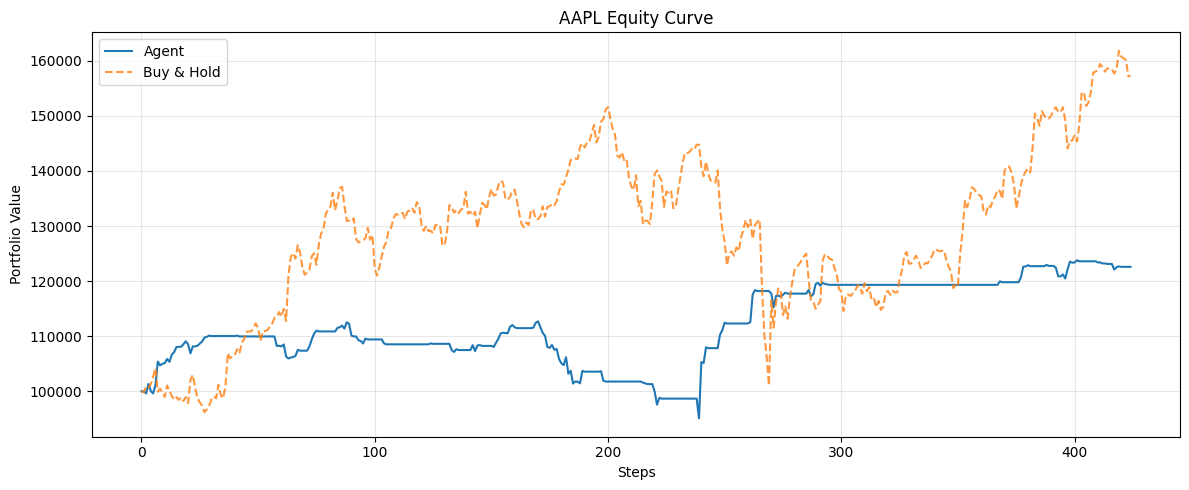

AMD
------------------------------------------------------------
Total Return: 64.4758%
Win Rate:     30.90%
Final Value:  164475.781250

Action Distribution:
  ALLOC_0    Count:  191 |  45.05%
  ALLOC_35   Count:    1 |   0.24%
  ALLOC_70   Count:  232 |  54.72%


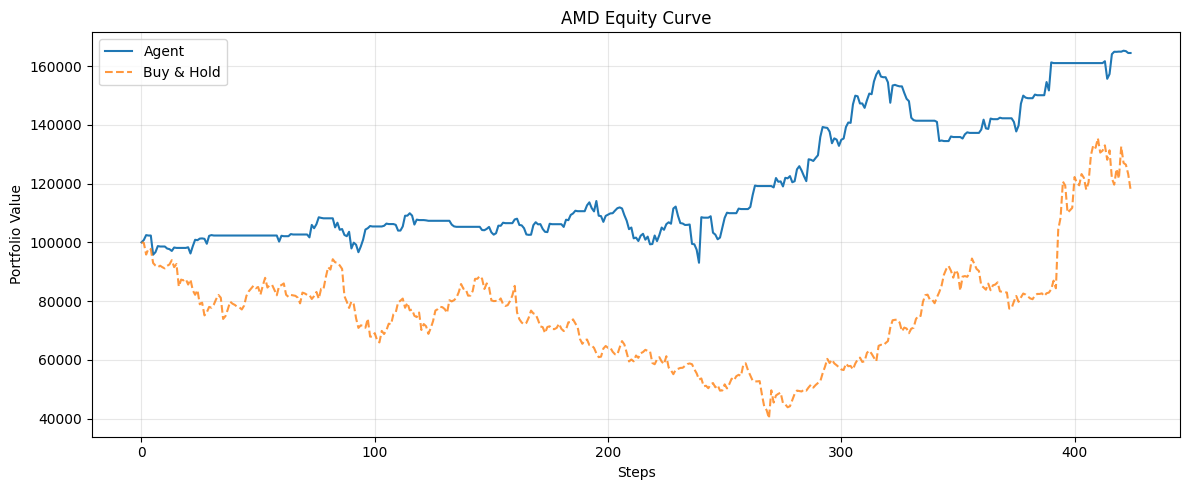

AMZN
------------------------------------------------------------
Total Return: 21.1744%
Win Rate:     12.97%
Final Value:  121174.398438

Action Distribution:
  ALLOC_0    Count:  325 |  76.65%
  ALLOC_35   Count:    3 |   0.71%
  ALLOC_70   Count:   96 |  22.64%


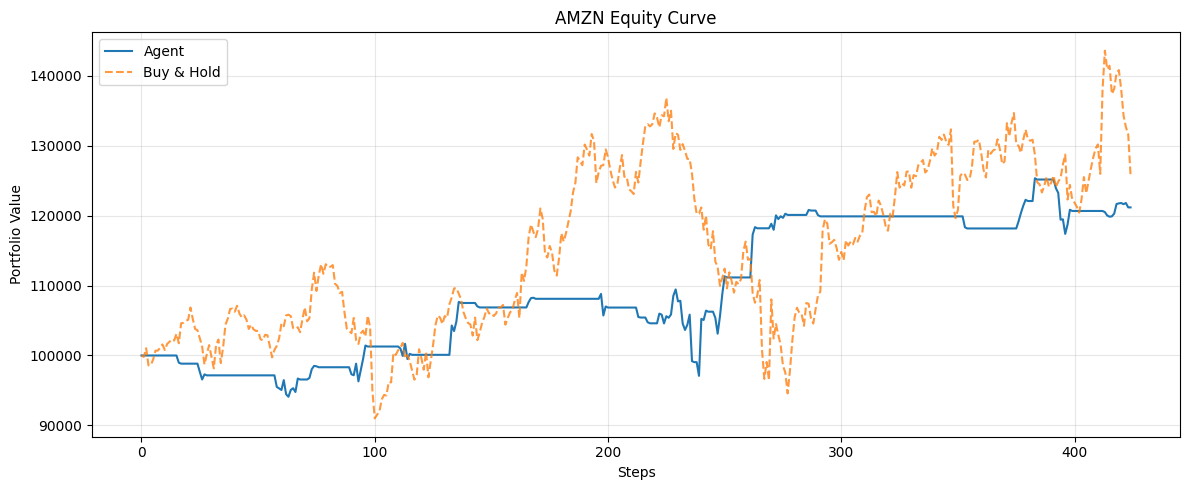

CSCO
------------------------------------------------------------
Total Return: 12.2209%
Win Rate:     16.98%
Final Value:  112220.875000

Action Distribution:
  ALLOC_0    Count:  289 |  68.16%
  ALLOC_35   Count:   15 |   3.54%
  ALLOC_70   Count:  120 |  28.30%


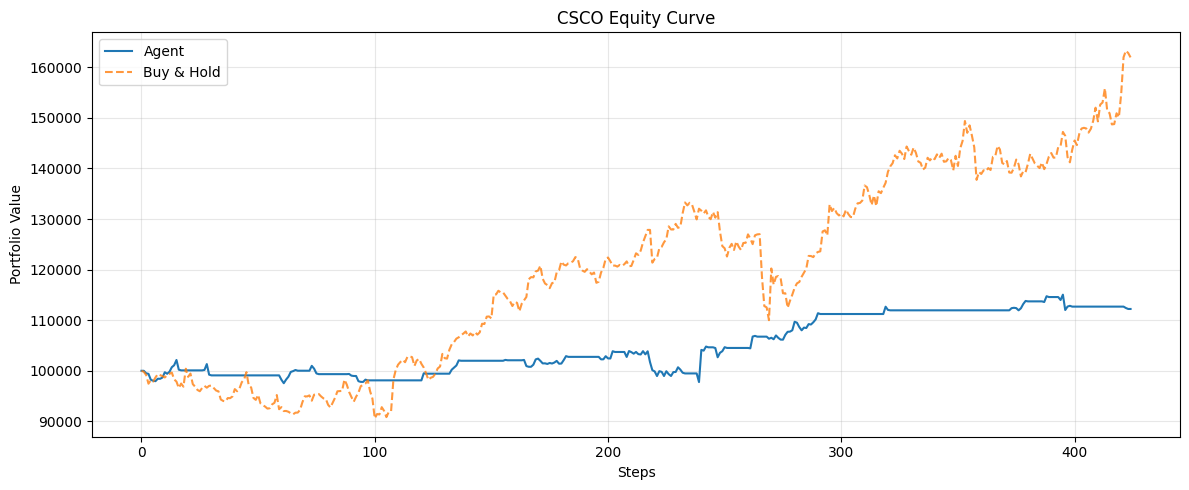

GOOGL
------------------------------------------------------------
Total Return: 4.7877%
Win Rate:     16.75%
Final Value:  104787.687500

Action Distribution:
  ALLOC_0    Count:  287 |  67.69%
  ALLOC_35   Count:   11 |   2.59%
  ALLOC_70   Count:  126 |  29.72%


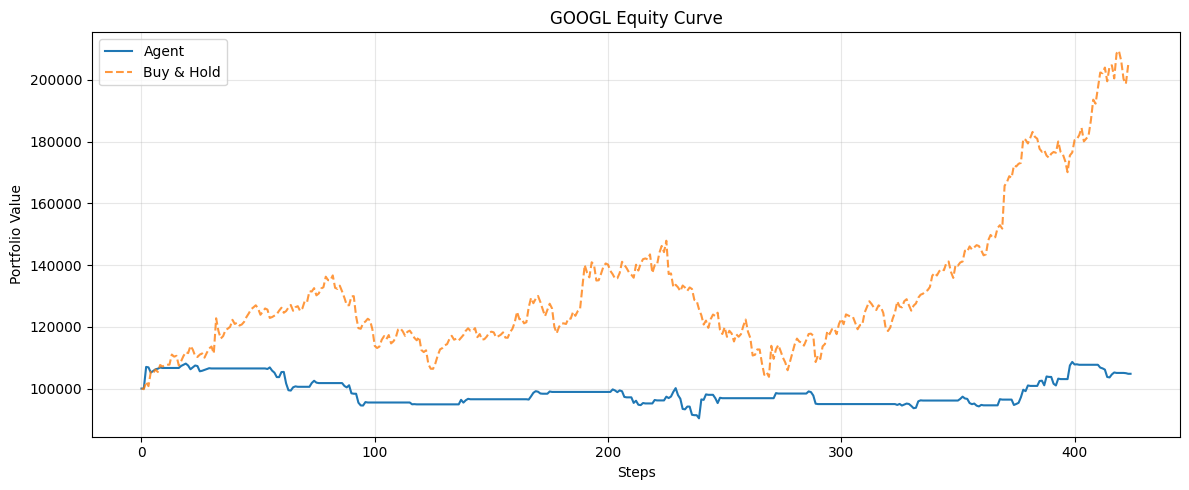

INTC
------------------------------------------------------------
Total Return: 95.3371%
Win Rate:     24.06%
Final Value:  195337.125000

Action Distribution:
  ALLOC_0    Count:  224 |  52.83%
  ALLOC_35   Count:    3 |   0.71%
  ALLOC_70   Count:  197 |  46.46%


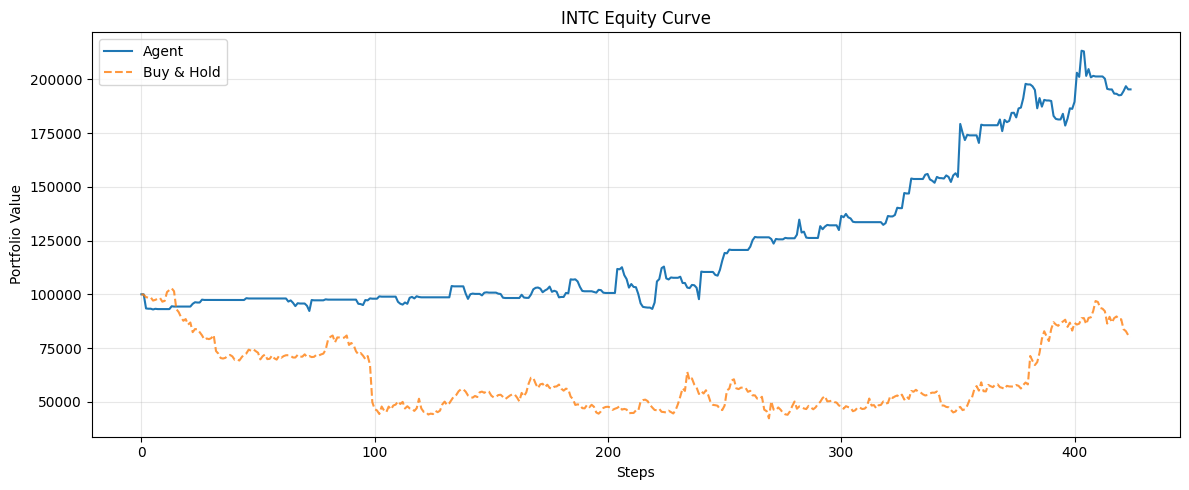

META
------------------------------------------------------------
Total Return: 28.3700%
Win Rate:     15.09%
Final Value:  128369.984375

Action Distribution:
  ALLOC_0    Count:  297 |  70.05%
  ALLOC_35   Count:    6 |   1.42%
  ALLOC_70   Count:  121 |  28.54%


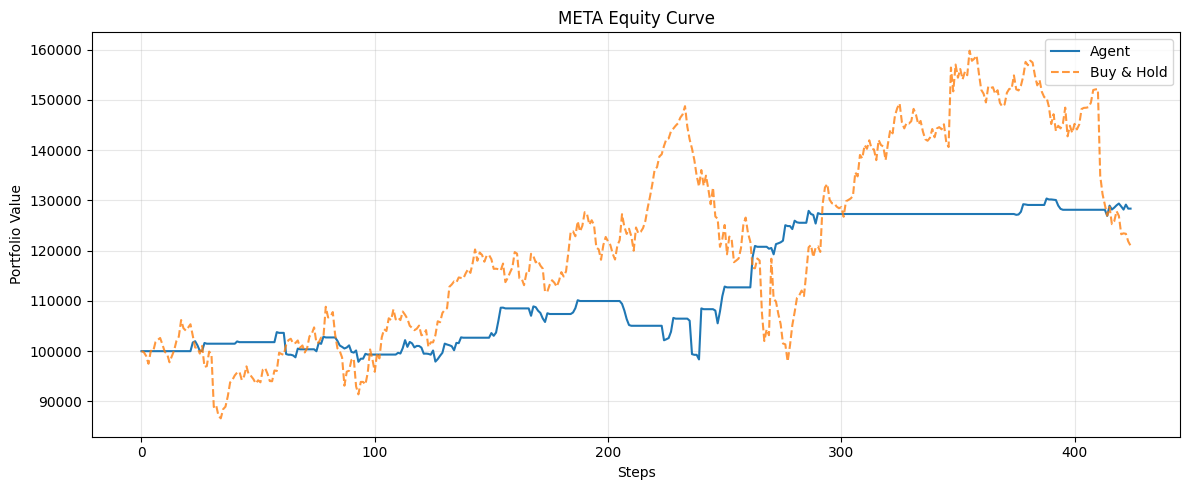

MSFT
------------------------------------------------------------
Total Return: 14.7697%
Win Rate:     22.17%
Final Value:  114769.734375

Action Distribution:
  ALLOC_0    Count:  257 |  60.61%
  ALLOC_35   Count:   13 |   3.07%
  ALLOC_70   Count:  154 |  36.32%


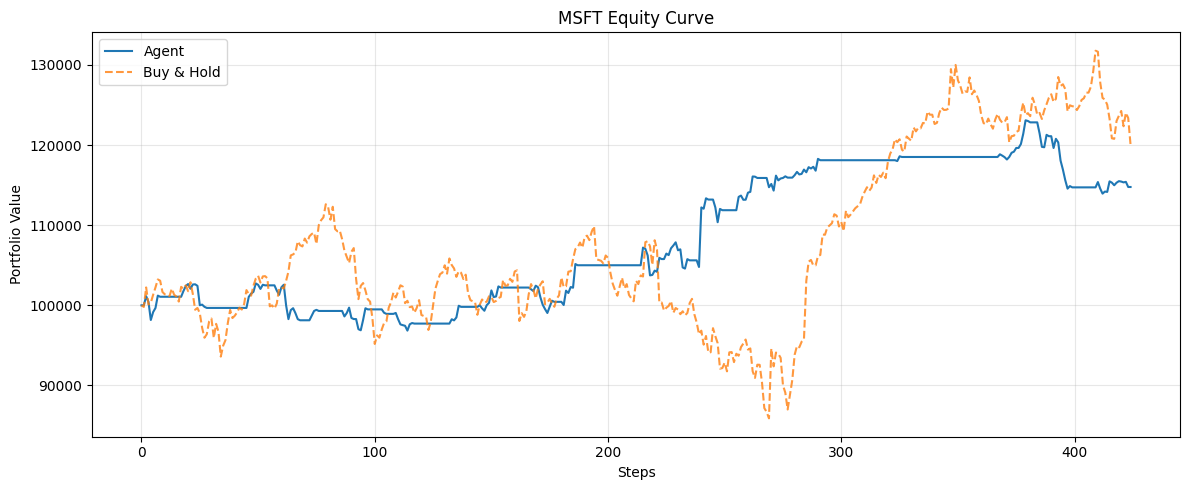

NVDA
------------------------------------------------------------
Total Return: 124.1952%
Win Rate:     28.30%
Final Value:  224195.218750

Action Distribution:
  ALLOC_0    Count:  224 |  52.83%
  ALLOC_35   Count:    2 |   0.47%
  ALLOC_70   Count:  198 |  46.70%


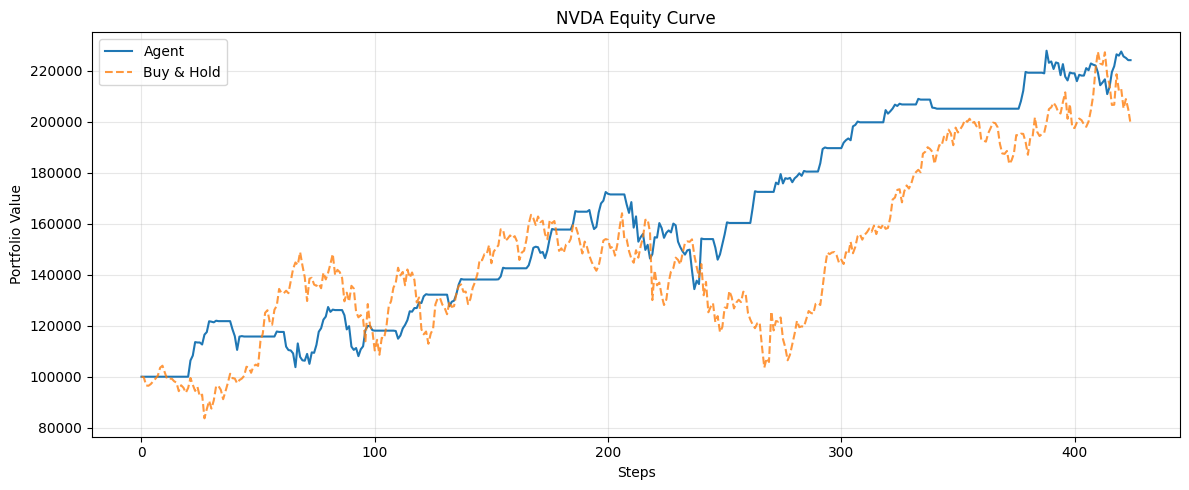

TSLA
------------------------------------------------------------
Total Return: 87.9215%
Win Rate:     31.13%
Final Value:  187921.468750

Action Distribution:
  ALLOC_0    Count:  176 |  41.51%
  ALLOC_35   Count:    1 |   0.24%
  ALLOC_70   Count:  247 |  58.25%


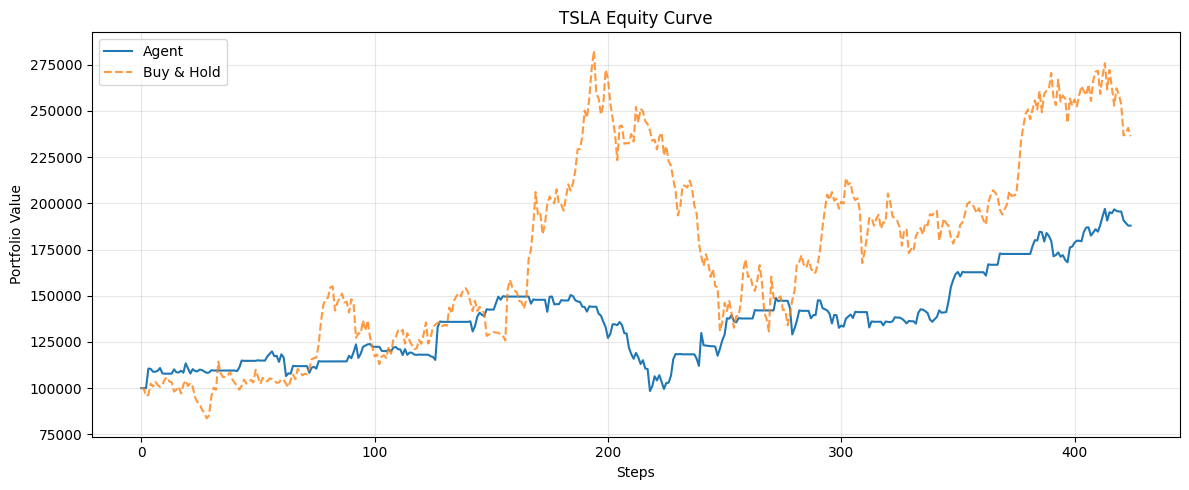

In [8]:
results_best_model = backtest(
    best_model,
    test_states,
    test_prices,
    tickers=tickers,
    steps_per_day=1
)

avg_return = sum(m['Total Return (%)'] for m in results_best_model.values()) / len(results_best_model)
print(f"Average Return: {avg_return:.4f}%")

for i, (ticker, metrics) in enumerate(results_best_model.items()):

    print("="*60)
    print(ticker)
    print("-"*60)

    print(f"Total Return: {metrics['Total Return (%)']:.4f}%")
    print(f"Win Rate:     {metrics['Win Rate (%)']:.2f}%")
    print(f"Final Value:  {metrics['Final Value']:.6f}")

    print("\nAction Distribution:")
    for action_name, stats in metrics["Action Distribution"].items():
        print(
            f"  {action_name:<10} "
            f"Count: {stats['count']:>4} | "
            f"{stats['percentage']:>6.2f}%"
        )

    print("="*60)

    #Buy & Hold Benchmark
    bh_equity = compute_buyhold_equity(test_prices[i])

    # Đảm bảo 2 curve cùng length
    min_len = min(len(metrics["Equity Curve"]), len(bh_equity))

    plot_equity(
        metrics["Equity Curve"][:min_len],
        title=f"{ticker} Equity Curve",
        benchmark=bh_equity[:min_len]
    )